Normalizing Flow: Coumpling - From Gaussian to a different distibrution

In [94]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [95]:
# Simple MLP with one hidden layer: 
# MLP stands for Multi-Layer Perceptron, which is a type of feedforward neural network.
# The `init_mlp` function initializes the parameters of the MLP, including the weights and biases for both layers.

def init_mlp(key, in_dim, hidden1, hidden2, out_dim):
    k1, k2 = jax.random.split(key)
    return {
        "W1": jax.random.normal(k1, (in_dim, hidden1)) * 0.1,
        "b1": jnp.zeros(hidden1),
        "W2": jax.random.normal(k2, (hidden1, hidden2)) * 0.1,
        "b2": jnp.zeros(hidden2),
        "W3": jax.random.normal(k2, (hidden2, out_dim)) * 0.1,
        "b3": jnp.zeros(out_dim),
    }
# The `mlp` function defines the forward pass of the MLP. It takes the input `x`,
# applies a linear transformation followed by a non-linear activation (tanh) for the hidden layer, 
# and then applies another linear transformation to produce the output.
def mlp(params, x):
    h1 = jnp.tanh(x @ params["W1"] + params["b1"])
    h2 = jnp.tanh(h1 @ params["W2"] + params["b2"])
    return h2 @ params["W3"] + params["b3"]

In [96]:
# The `coupling_forward` function implements the forward pass of a coupling layer.
# the mask is a vector that determines which part of the input is transformed and which part is left unchanged.
# example mask = [1, 0] means that the first part of the input is transformed while the second part is left unchanged.

def coupling_forward(params, x, mask):
    x_masked = x * mask
    
    st = mlp(params, x_masked) # we pass to the MLP the masked input.
    s, t = jnp.split(st, 2, axis=-1) # we split the output of the MLP into two parts: s and t.
    
    s = 0.1 * jnp.tanh(s)  # we scale s to ensure that the exponential does not explode.
    
    y = x_masked + (1 - mask) * (x * jnp.exp(s) + t) # we compute the output of the coupling layer. 
    # The masked part of the input is added to the transformed part.
    # note: we use the exponential of s to ensure that the transformation is invertible.
    # note: where the mask is 1, we keep the input unchanged, and where the mask is 0, we apply the transformation.
    # note: where the mask is 0, we are aplying an affine transformation to the input, 
    # where the scale is given by exp(s) and the translation is given by t.
    log_det = jnp.sum((1 - mask) * s, axis=-1)
    # the jacobian is triangular, so the log determinant 
    # is just the sum of the log of the diagonal elements, which are given by s.
    return y, log_det

# we need to create masks for each layer of the coupling layers.
def create_masks(n_layers):
    masks = []
    for i in range(n_layers):
        masks.append(jnp.array([1., 0.]) if i % 2 == 0 else jnp.array([0., 1.]))
        # we are crating [1, 0] for even layers and [0, 1] for odd layers
        #  to ensure that we are transforming different parts of the input in each layer.
    return masks

In [97]:
# The `forward` function applies a sequence of coupling layers to the input `z`,
#  using the provided parameters and masks.
def forward(params, masks, z):
    log_det = 0.
    x = z
    
    for p, m in zip(params, masks):
        x, ld = coupling_forward(p, x, m)
        log_det += ld  
        # the transformation are composed, so the log determinants are added.
        
    return x, log_det

In [98]:
# The `log_prob_z` function computes the log probability of the base variable `z` 
# under a standard normal distribution.
def log_prob_z(z):
    return -0.5 * jnp.sum(z**2, axis=-1)

Esemple Target:

In [99]:
def log_prob_target(x, beta=1.0, a=1.0):
    x1 = x[..., 0]
    x2 = x[..., 1]
    
    V = a * (x1**2 - 1.0)**2 + 0.5 * x2**2
    return -beta * V

Loss 

In [100]:
def loss_fn(params, masks, key, n=256):
    z = jax.random.normal(key, (n, 2))
    
    x, log_det = forward(params, masks, z)
    
    log_q = log_prob_z(z) - log_det
    log_p = log_prob_target(x)
    
    return jnp.mean(log_q - log_p)

In [101]:
# eta is the learning rate, which controls how much we update the parameters in each step.

@jax.jit
def train_step(params, masks, key, eta=1e-3):
    loss, grads = jax.value_and_grad(loss_fn)(params, masks, key)
    # we compute the gradients of the loss with respect to the parameters using `jax.value_and_grad`.
    # `jax.value_and_grad` is a convenient function that returns 
    # both the value of the loss and its gradients with respect to the parameters.
    
    params = jax.tree_util.tree_map(lambda p, g: p - eta * g, params, grads)
    # we update the parameters using a simple gradient descent step,
    # where we subtract the learning rate multiplied by the gradients from the current parameters.
    
    return params, loss

In [102]:
key = jax.random.PRNGKey(0)

n_layers = 8
keys = jax.random.split(key, n_layers)
params = [init_mlp(k, 2, 64, 14, 4) for k in keys]
masks = create_masks(n_layers)
loss_history = []
n_steps = 80000
eta = 1e-2

for step in range(n_steps):
    key, subkey = jax.random.split(key)
    params, loss = train_step(params, masks, subkey, eta)
    loss_history.append(loss)

Plot of the Loss

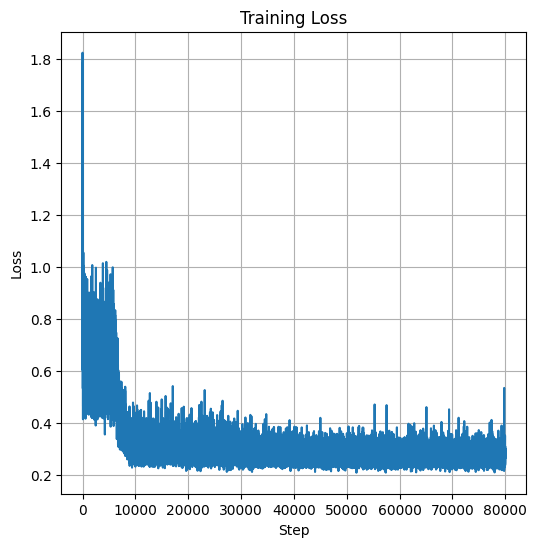

In [103]:
plt.figure(figsize=(6, 6))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()

In [104]:
def sample(params, masks, key, n=1000):
    z = jax.random.normal(key, (n, 2))
    x, _ = forward(params, masks, z)
    return x

Sampling and Plotting the 2 distibrution

Text(0.5, 1.0, 'Transformed Distribution (x)')

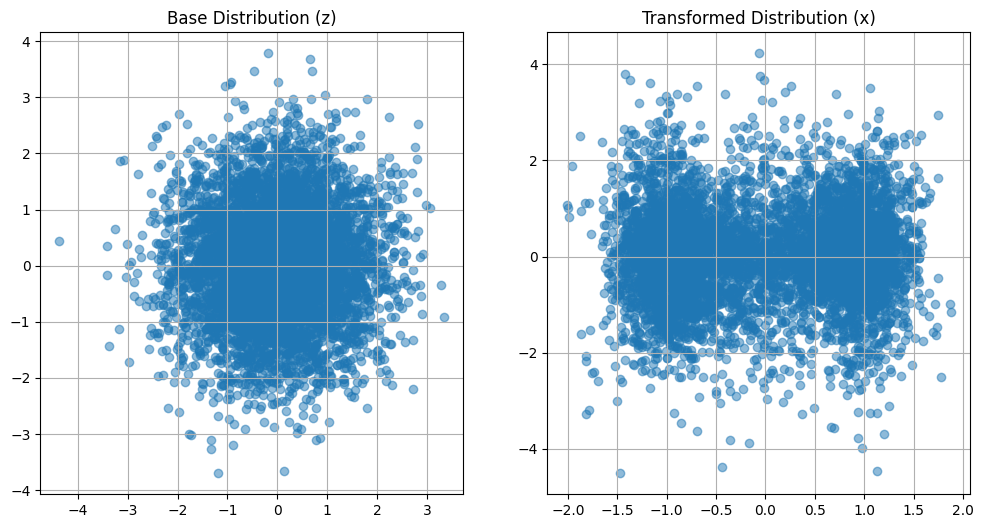

In [105]:
n_samples = 6000
z = jax.random.normal(key, (n_samples, 2))
x = sample(params, masks, key, n_samples)

# before and after the transformation plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.grid()
plt.scatter(z[:, 0], z[:, 1], alpha=0.5)
plt.title("Base Distribution (z)")
plt.subplot(1, 2, 2)
plt.grid()
plt.scatter(x[:, 0], x[:, 1], alpha=0.5)
plt.title("Transformed Distribution (x)")